# Competicion Kaggle - Grupo 22 - Predicción de Diabetes

Esta competencia ha sido creada a partir de un datasets sobre una recopilación de datos médicos y demográficos de los pacientes, junto con su estado de diabetes (positivo o negativo). Los datos incluyen características como la edad, el sexo, el índice de masa corporal (IMC), la hipertensión, las enfermedades cardíacas, el historial de tabaquismo, el nivel de HbA1c y el nivel de glucosa en sangre. Este conjunto de datos se puede usar para construir modelos de aprendizaje automático para predecir la diabetes en pacientes en función de su historial médico e información demográfica. Esto puede ser útil para los profesionales de la salud en la identificación de pacientes que pueden estar en riesgo de desarrollar diabetes y en el desarrollo de planes de tratamiento personalizados. Además, los investigadores pueden utilizar el conjunto de datos para explorar las relaciones entre varios factores médicos y demográficos y la probabilidad de desarrollar diabetes.

### 1) IMPORTACION DE LIBRERIAS

In [ ]:
!pip install -U imbalanced-learn
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.8/253.8 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 3.3 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import neural_network
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix, precision_score, f1_score, recall_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, recall_score, roc_auc_score,RocCurveDisplay
#from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,

### 2) ANALISIS DEL DATA SET

#### 2.1) DATA SET TRAIN

In [ ]:
# Cargar los datos de entrenamiento

#from google.colab import files
#uploaded = files.upload()

train_df = pd.read_csv('diabetes_prediction_dataset_train-labeled.csv')

Saving diabetes_prediction_dataset_train-labeled.csv to diabetes_prediction_dataset_train-labeled.csv


Hacemos un analisis estadistico y descriptivo del set de datos de entrenamiento

Tamaño del set de datos:

In [ ]:
# Imprimir el tamaño del set de datos
print(f"El set de datos de entrenamiento tiene {train_df.shape[0]} filas y {train_df.shape[1]} columnas.")
train_df.head()

El set de datos de entrenamiento tiene 95000 filas y 10 columnas.


,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0


Analisis estadistico

In [ ]:
# Mostrar el análisis estadístico descriptivo
display(train_df.describe())


,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,50016.501389,41.935269,0.075074,0.039463,27.320879,5.527659,138.070537,0.085074
std,28868.357071,22.514788,0.263512,0.194695,6.626335,1.070261,40.739962,0.278993
min,1.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,25021.750000,24.000000,0.000000,0.000000,23.650000,4.800000,100.000000,0.000000
50%,50024.000000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,75024.250000,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,100000.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
# Calculate the mode of the 'bmi' column in the training data
bmi_mode = train_df['bmi'].mode()

# Check if mode is not empty and get the first mode value
if not bmi_mode.empty:
    first_bmi_mode = bmi_mode[0]

    # Count the occurrences of the mode value in the 'bmi' column
    bmi_mode_count = train_df['bmi'].eq(first_bmi_mode).sum()

    # Print the mode and its count
    print("The mode of the 'bmi' column in the training dataset is:")
    print(first_bmi_mode)
    print(f"\nNumber of records with this BMI ({first_bmi_mode}): {bmi_mode_count}")
else:
    print("Could not determine the mode of the 'bmi' column.")

The mode of the 'bmi' column in the training dataset is:
27.32

Number of records with this BMI (27.32): 24252


Se muestra la informacion general

In [ ]:
# Mostrar información general del set de datos
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


* No hay datos nulos.
* Solo hay 2 columnas categoricas ('gender' y 'smoking_history')

Graficos

##### Visualización general de la distribución de las variables numéricas.

array([[<Axes: title={'center': 'patient'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hypertension'}>],
       [<Axes: title={'center': 'heart_disease'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'HbA1c_level'}>],
       [<Axes: title={'center': 'blood_glucose_level'}>,
        <Axes: title={'center': 'diabetes'}>, <Axes: >]], dtype=object)

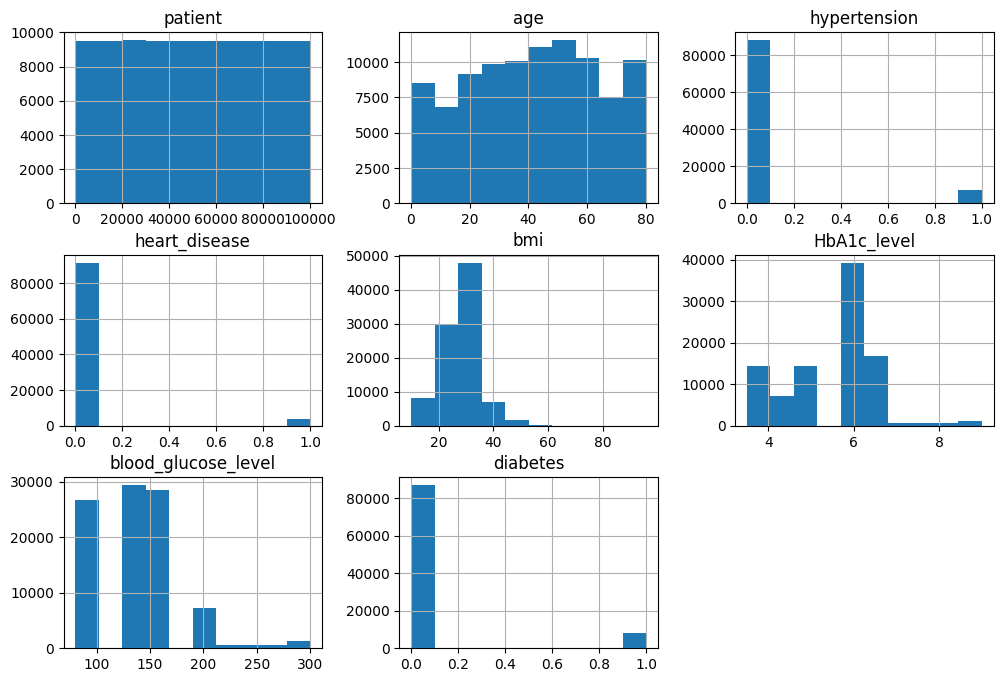

In [ ]:
train_df.hist(figsize=(12, 8))

##### Variable diabetes

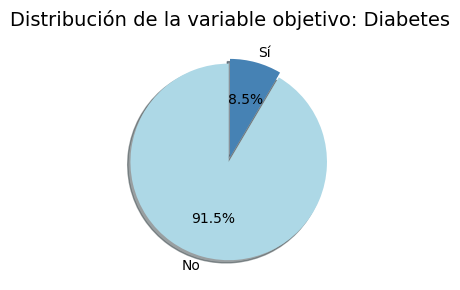

In [ ]:
# Realizamos el conteo de valores de la variable diabetes
diabetes_counts = train_df['diabetes'].value_counts()
labels = ['No', 'Sí']
colors = ['lightblue', 'steelblue']
explode = (0.05, 0)  # Resaltar la clase positiva

# Crear gráfico de torta
plt.figure(figsize=(3, 3))
plt.pie(
    diabetes_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True
)
plt.title("Distribución de la variable objetivo: Diabetes", fontsize=14)
plt.tight_layout()
plt.show()


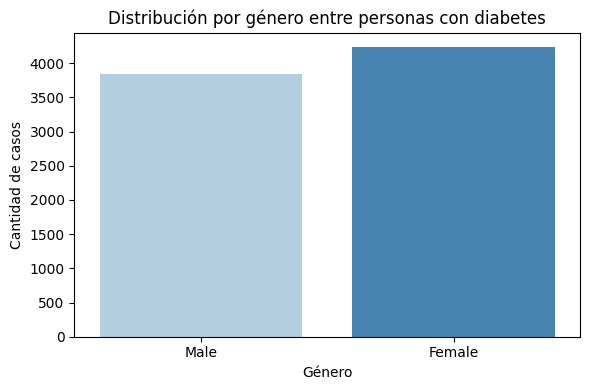

In [ ]:
# Filtrar solo personas con diabetes
df_diabetes = train_df[train_df['diabetes'] == 1]

# Conteo por género
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df_diabetes, palette='Blues')

# Detalles del gráfico
plt.title("Distribución por género entre personas con diabetes")
plt.xlabel("Género")
plt.ylabel("Cantidad de casos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:

# Filtramos personas con diabetes
df_diabetes = train_df[train_df['diabetes'] == 1].copy()

# Agrupamos en rangos de edad
df_diabetes['grupo_edad'] = pd.cut(
    df_diabetes['age'],
    bins=[0, 30, 45, 60, 75, 100],
    labels=['<30', '31-45', '46-60', '61-75', '76+']
)

# Gráficamos de barras agrupadas por género y grupo de edad
plt.figure(figsize=(8, 5))
sns.countplot(data=df_diabetes, x='grupo_edad', hue='gender', palette='Blues')

plt.title("Distribución por género y edad en personas con diabetes")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de casos")
plt.legend(title="Género")
plt.tight_layout()
plt.show()


##### Variable categorica gender

In [ ]:
# Contar los valores únicos en la columna 'gender' de todo nuestro dataset
print(train_df['gender'].value_counts())

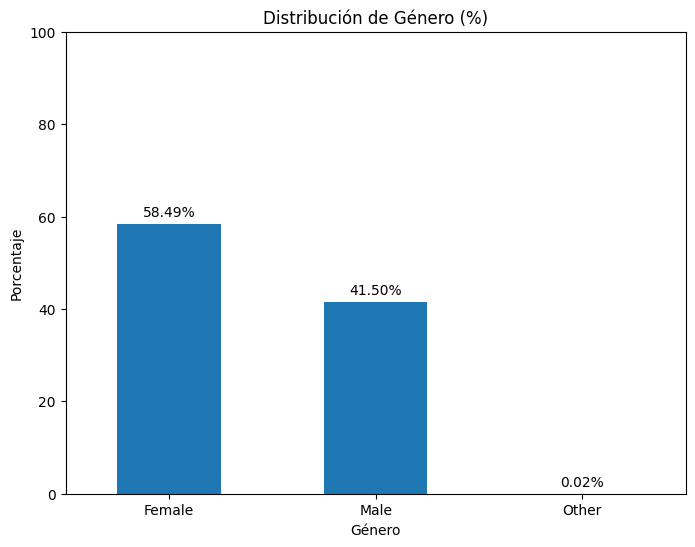

<Figure size 600x400 with 0 Axes>

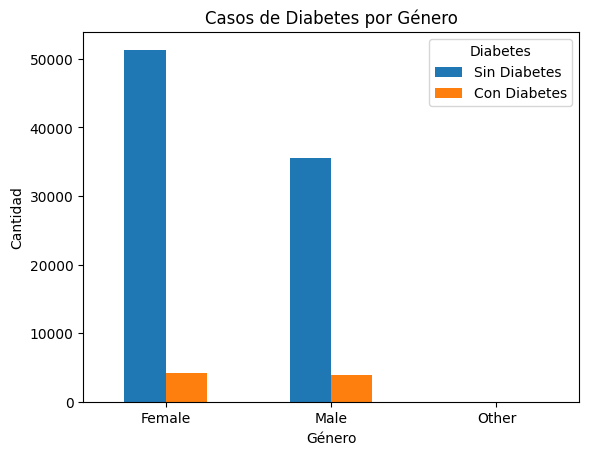

In [ ]:
# Calcular conteos y porcentajes de género
gender_counts = train_df['gender'].value_counts()
gender_percentages = gender_counts / len(train_df) * 100

plt.figure(figsize=(8, 6))
bars = gender_percentages.plot(kind='bar')
plt.title('Distribución de Género (%)')
plt.xlabel('Género')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Añadir etiquetas de porcentaje a las barras
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')

plt.show()

# Gráfico de barras agrupadas de diabetes por género
plt.figure(figsize=(6, 4))
pd.crosstab(train_df['gender'], train_df['diabetes']).plot(kind='bar', stacked=False)
plt.title('Casos de Diabetes por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.legend(title='Diabetes', labels=['Sin Diabetes', 'Con Diabetes'])
plt.show()

##### Variable age

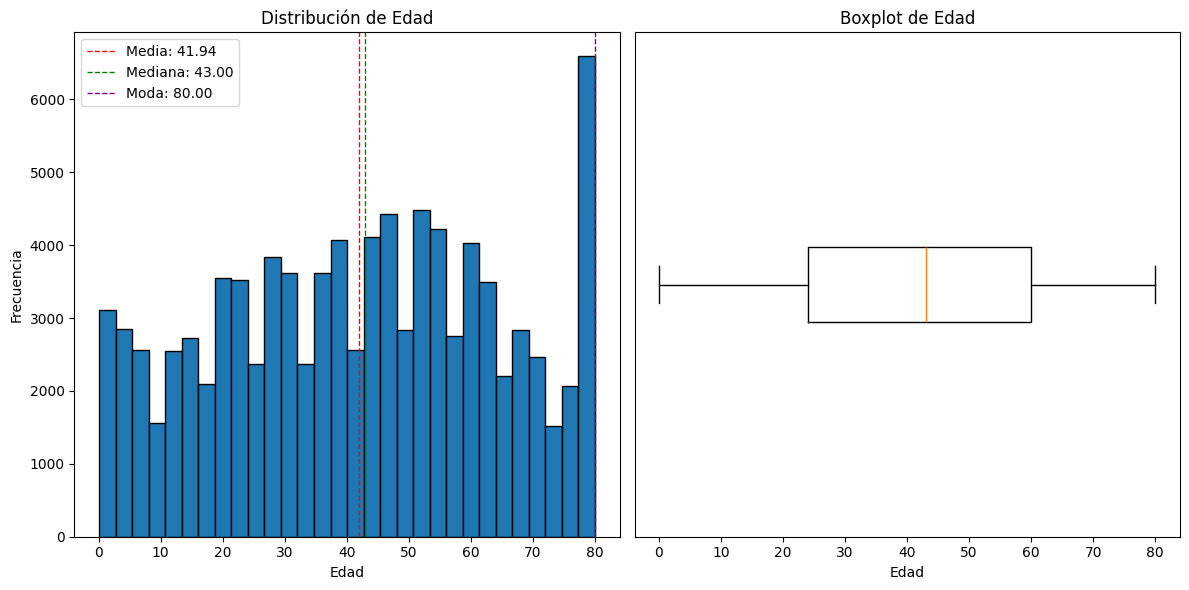

In [ ]:
plt.figure(figsize=(12, 6))

# Calcular media, mediana y moda
mean_age = train_df['age'].mean()
median_age = train_df['age'].median()
# Moda puede tener múltiples valores, tomamos el primero si existe
mode_age = train_df['age'].mode()
if not mode_age.empty:
    mode_age_val = mode_age[0]
else:
    mode_age_val = None


# Histograma de age
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.hist(train_df['age'], bins=30, edgecolor='black')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Añadir líneas para media, mediana y moda
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=1, label=f'Media: {mean_age:.2f}')
plt.axvline(median_age, color='green', linestyle='dashed', linewidth=1, label=f'Mediana: {median_age:.2f}')
if mode_age_val is not None:
    plt.axvline(mode_age_val, color='purple', linestyle='dashed', linewidth=1, label=f'Moda: {mode_age_val:.2f}')

plt.legend()

# Boxplot de age
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.boxplot(train_df['age'], vert=False)
plt.title('Boxplot de Edad')
plt.xlabel('Edad')
plt.yticks([]) # Ocultar etiquetas del eje y para el boxplot

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

* No se observan valores extremos.
* Se observa que el promedio esta cerca de los 40 años.
* El valor que mas se repite son los cercano a los 80.

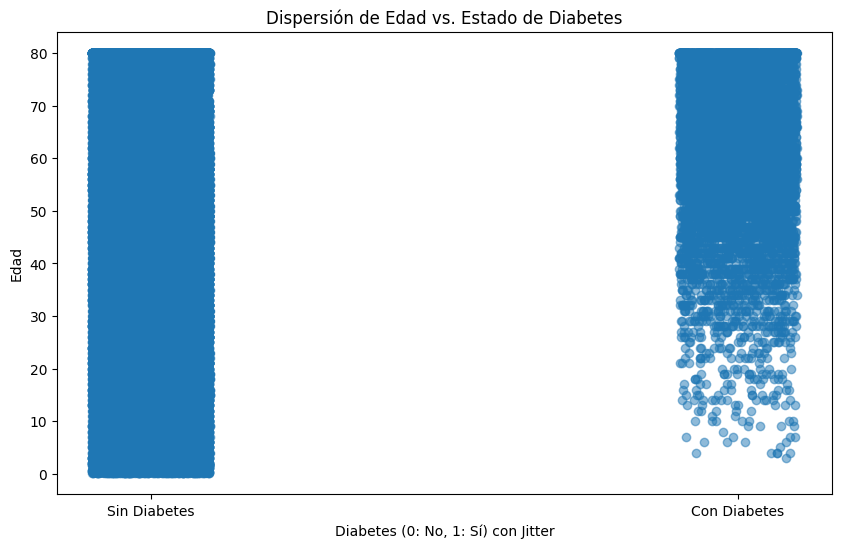

In [ ]:
plt.figure(figsize=(10, 6))

# Añadir jitter a la columna 'diabetes' para visualizar puntos superpuestos
jittered_diabetes = train_df['diabetes'] + np.random.uniform(-0.1, 0.1, size=len(train_df))

plt.scatter(jittered_diabetes, train_df['age'], alpha=0.5)
plt.title('Dispersión de Edad vs. Estado de Diabetes')
plt.xlabel('Diabetes (0: No, 1: Sí) con Jitter')
plt.ylabel('Edad')
plt.xticks([0, 1], ['Sin Diabetes', 'Con Diabetes'])
plt.show()

##### Variable hypertension    

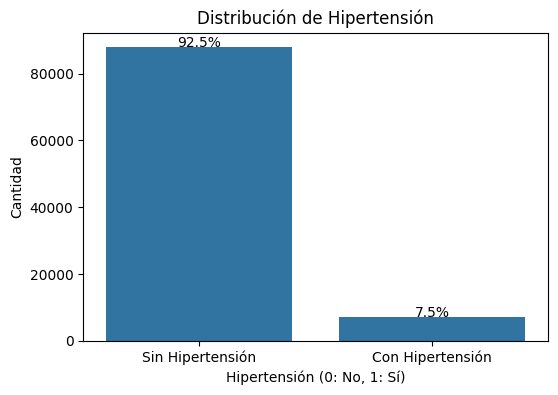

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='hypertension', data=train_df)
plt.title('Distribución de Hipertensión')
plt.xlabel('Hipertensión (0: No, 1: Sí)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Sin Hipertensión', 'Con Hipertensión'])

# Añadir porcentajes encima de las barras
total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(100 * height/total),
            ha="center")

plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
crosstab_ht_diabetes = pd.crosstab(train_df['hypertension'], train_df['diabetes'])
ax = crosstab_ht_diabetes.plot(kind='bar', stacked=False)

plt.title('Casos de Diabetes por Hipertensión con Porcentajes')
plt.xlabel('Hipertensión')
plt.ylabel('Cantidad')
ax.set_xticklabels(['Sin Hipertensión', 'Con Hipertensión'], rotation=0)
plt.legend(title='Diabetes', labels=['Sin Diabetes', 'Con Diabetes'])

# Añadir porcentajes encima de las barras
for i, container in enumerate(ax.containers):
    for j, p in enumerate(container.patches):
        height = p.get_height()
        # Usar el índice de la barra (j) para obtener el total para ese grupo de hipertensión
        total_in_group = crosstab_ht_diabetes.iloc[j].sum()
        percentage = (height / total_in_group) * 100 if total_in_group > 0 else 0
        ax.text(p.get_x() + p.get_width()/2., height + 5,
                '{:1.1f}%'.format(percentage),
                ha="center")

plt.show()

##### Variable heart_disease

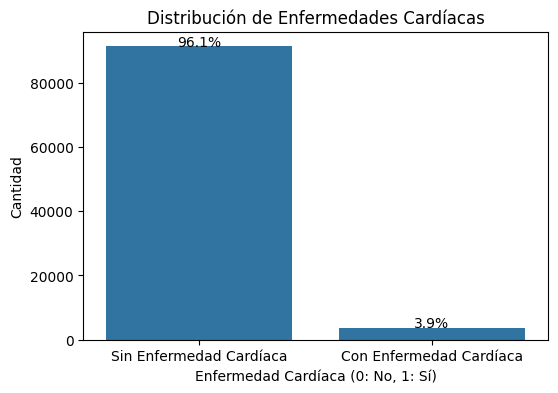

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='heart_disease', data=train_df)
plt.title('Distribución de Enfermedades Cardíacas')
plt.xlabel('Enfermedad Cardíaca (0: No, 1: Sí)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Sin Enfermedad Cardíaca', 'Con Enfermedad Cardíaca'])

# Añadir porcentajes encima de las barras
total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(100 * height/total),
            ha="center")

plt.show()

<Figure size 800x600 with 0 Axes>

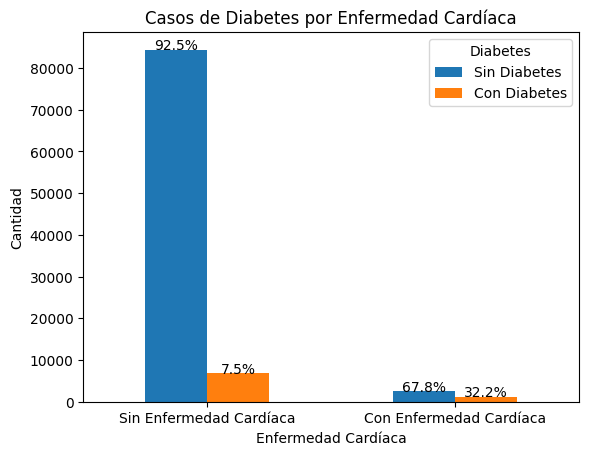

In [ ]:
plt.figure(figsize=(8, 6))
crosstab_hd_diabetes = pd.crosstab(train_df['heart_disease'], train_df['diabetes'])
ax = crosstab_hd_diabetes.plot(kind='bar', stacked=False)

plt.title('Casos de Diabetes por Enfermedad Cardíaca')
plt.xlabel('Enfermedad Cardíaca')
plt.ylabel('Cantidad')
ax.set_xticklabels(['Sin Enfermedad Cardíaca', 'Con Enfermedad Cardíaca'], rotation=0)
plt.legend(title='Diabetes', labels=['Sin Diabetes', 'Con Diabetes'])

# Añadir porcentajes encima de las barras
for i, container in enumerate(ax.containers):
    for j, p in enumerate(container.patches):
        height = p.get_height()
        # Usar el índice de la barra (j) para obtener el total para ese grupo de enfermedad cardíaca
        total_in_group = crosstab_hd_diabetes.iloc[j].sum()
        percentage = (height / total_in_group) * 100 if total_in_group > 0 else 0
        ax.text(p.get_x() + p.get_width()/2., height + 5,
                '{:1.1f}%'.format(percentage),
                ha="center")

plt.show()

##### Variable smoking_history

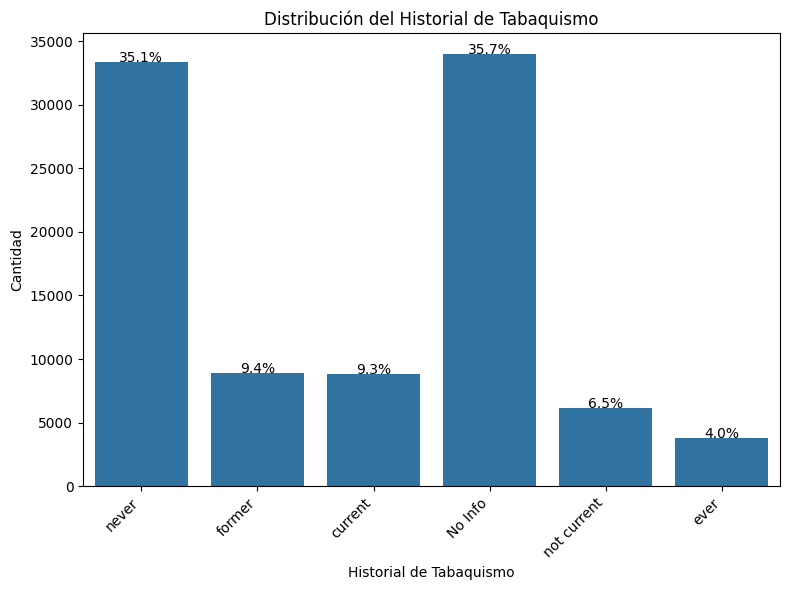

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='smoking_history', data=train_df)
plt.title('Distribución del Historial de Tabaquismo')
plt.xlabel('Historial de Tabaquismo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

# Añadir porcentajes encima de las barras
total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(100 * height/total),
            ha="center")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

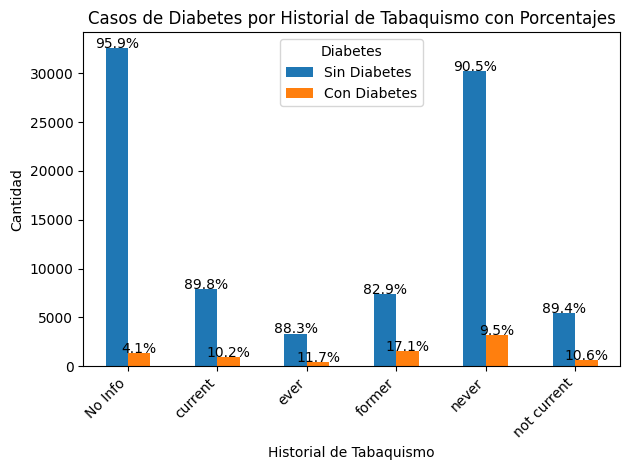

In [ ]:
plt.figure(figsize=(10, 6))
crosstab_sh_diabetes = pd.crosstab(train_df['smoking_history'], train_df['diabetes'])
ax = crosstab_sh_diabetes.plot(kind='bar', stacked=False)

plt.title('Casos de Diabetes por Historial de Tabaquismo con Porcentajes')
plt.xlabel('Historial de Tabaquismo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Diabetes', labels=['Sin Diabetes', 'Con Diabetes'])

# Añadir porcentajes encima de las barras
for i, container in enumerate(ax.containers):
    for j, p in enumerate(container.patches):
        height = p.get_height()
        # Use the index of the bar (j) to get the total for that smoking history group
        total_in_group = crosstab_sh_diabetes.iloc[j].sum()
        percentage = (height / total_in_group) * 100 if total_in_group > 0 else 0
        ax.text(p.get_x() + p.get_width()/2., height + 5,
                '{:1.1f}%'.format(percentage),
                ha="center")

plt.tight_layout()
plt.show()

##### Variable bmi             

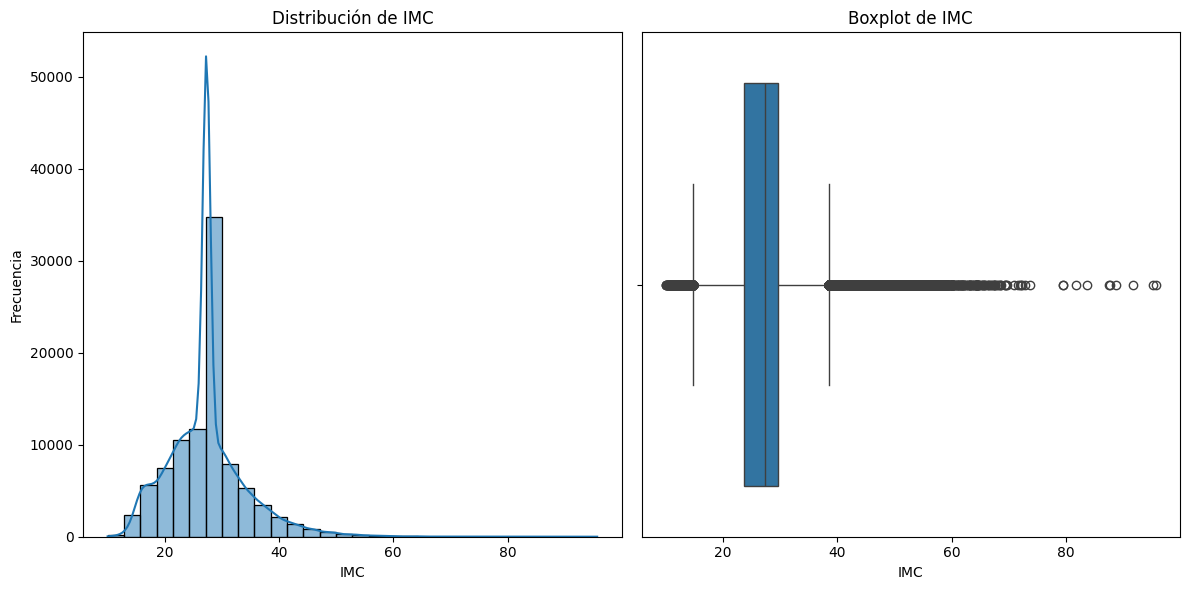

In [ ]:
plt.figure(figsize=(12, 6))

# Histograma de bmi
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(data=train_df, x='bmi', bins=30, kde=True)
plt.title('Distribución de IMC')
plt.xlabel('IMC')
plt.ylabel('Frecuencia')

# Boxplot de bmi
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(data=train_df, x='bmi')
plt.title('Boxplot de IMC')
plt.xlabel('IMC')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##### Variable HbA1c_level

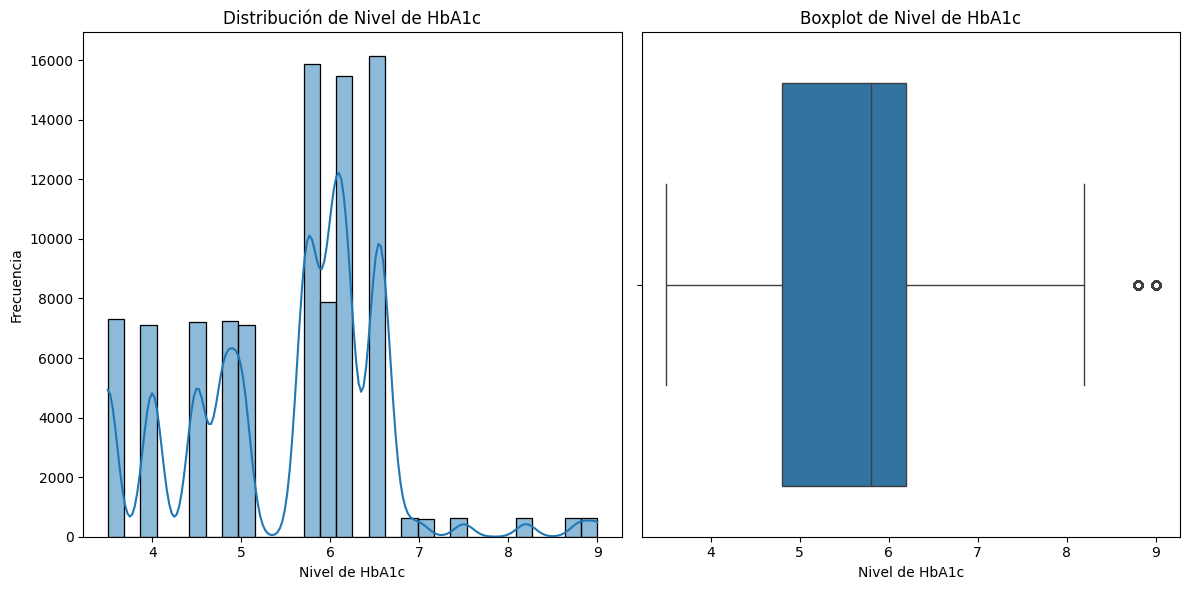

In [ ]:
plt.figure(figsize=(12, 6))

# Histograma de HbA1c_level
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(data=train_df, x='HbA1c_level', bins=30, kde=True)
plt.title('Distribución de Nivel de HbA1c')
plt.xlabel('Nivel de HbA1c')
plt.ylabel('Frecuencia')

# Boxplot de HbA1c_level
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(data=train_df, x='HbA1c_level')
plt.title('Boxplot de Nivel de HbA1c')
plt.xlabel('Nivel de HbA1c')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##### Variable blood_glucose_level

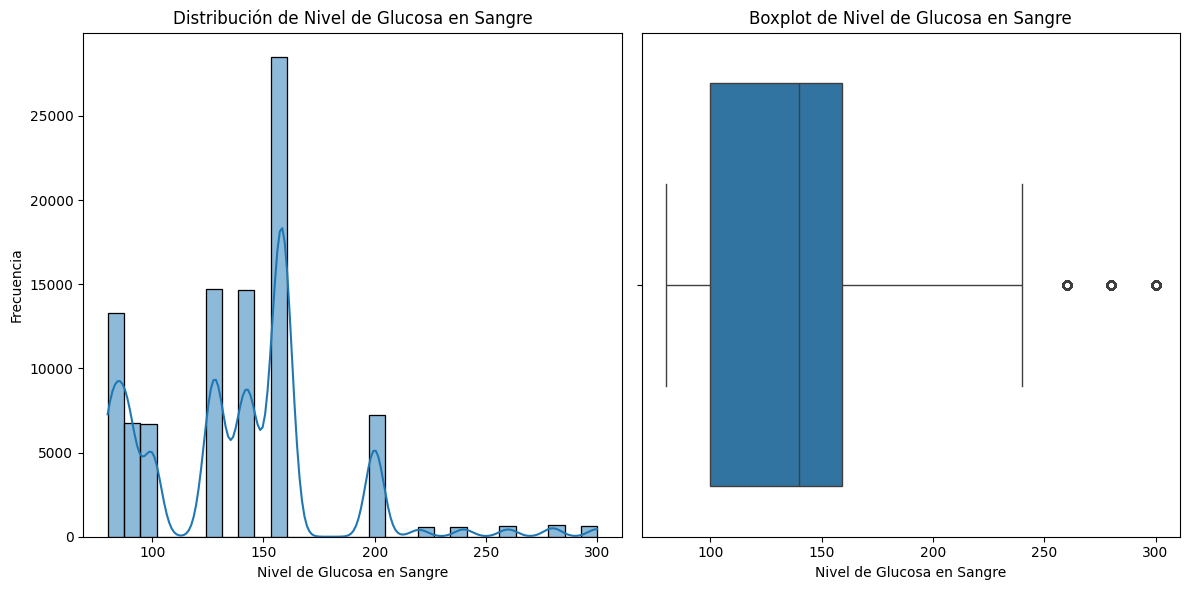

In [ ]:
plt.figure(figsize=(12, 6))

# Histograma de blood_glucose_level
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(data=train_df, x='blood_glucose_level', bins=30, kde=True)
plt.title('Distribución de Nivel de Glucosa en Sangre')
plt.xlabel('Nivel de Glucosa en Sangre')
plt.ylabel('Frecuencia')

# Boxplot de blood_glucose_level
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(data=train_df, x='blood_glucose_level')
plt.title('Boxplot de Nivel de Glucosa en Sangre')
plt.xlabel('Nivel de Glucosa en Sangre')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

Correlacion

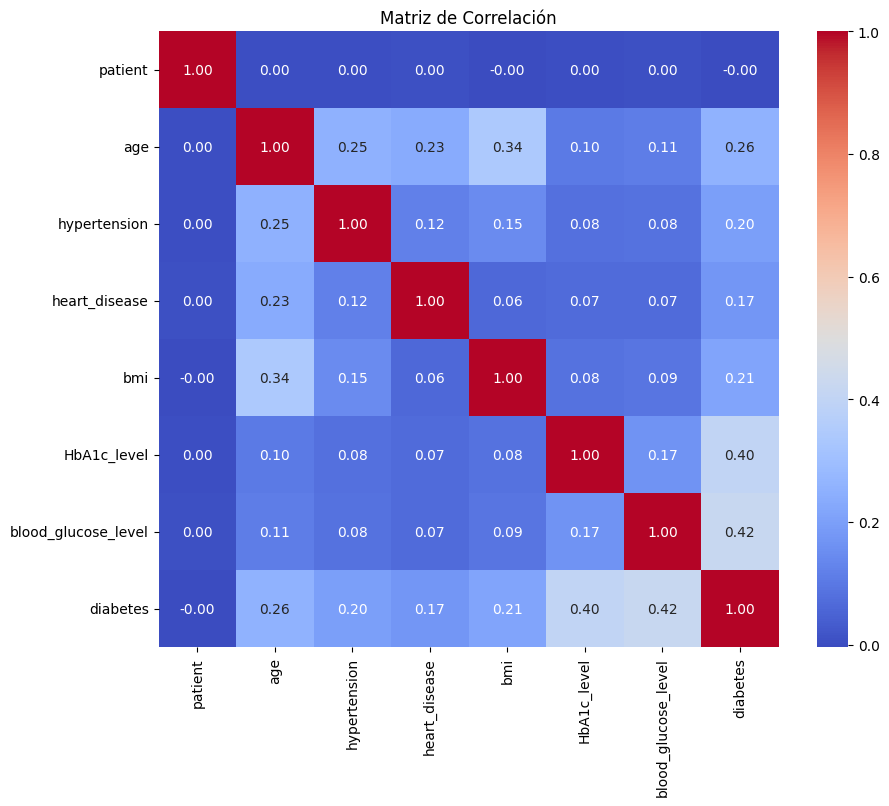

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = train_df.corr(numeric_only=True)

# Mostrar la matriz de correlación usando un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

## Seleccionamos menos variables para el analisis

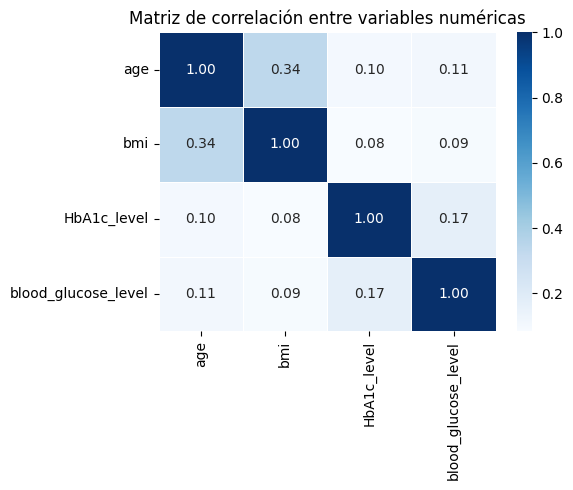

In [ ]:
# Selección de variables numéricas de interés
variables_numericas = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Calcular matriz de correlación
correlaciones = train_df[variables_numericas].corr()

# Visualizar heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlaciones,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()


Validamos que HbA1c_level y blood_glucose_level están altamente correlacionadas, mientras que age y bmi tienen menor relación con otras variables.

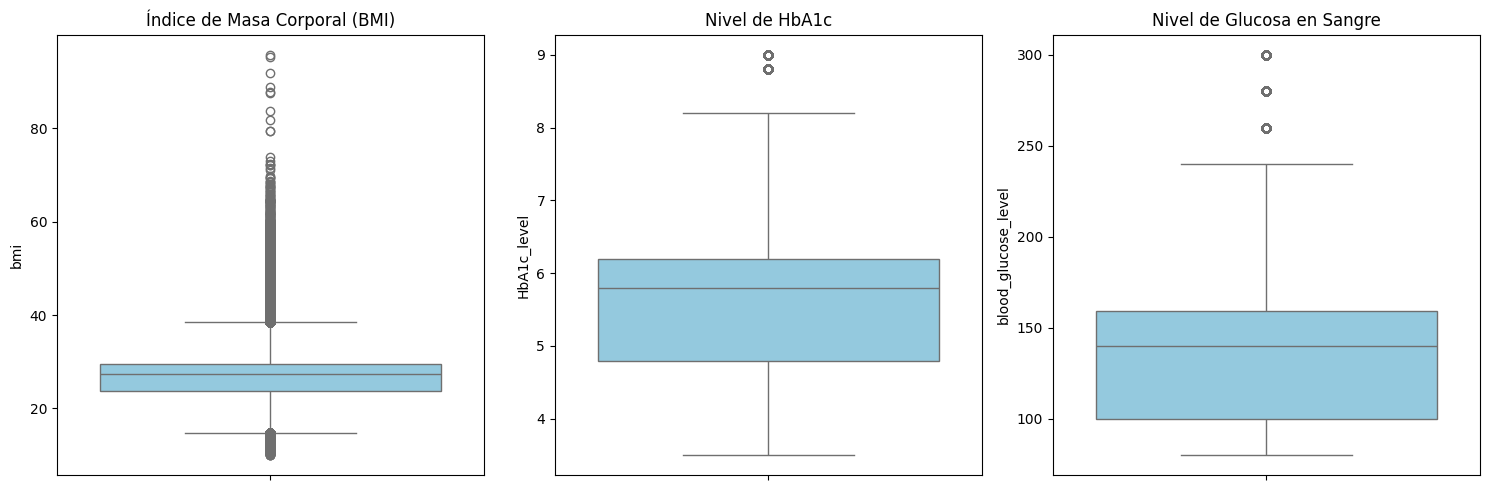

In [ ]:

# Lista de variables a graficar
variables = ['bmi', 'HbA1c_level', 'blood_glucose_level']
titulos = ['Índice de Masa Corporal (BMI)', 'Nivel de HbA1c', 'Nivel de Glucosa en Sangre']

# Crear una figura con subplots
plt.figure(figsize=(15, 5))

# Generar un boxplot para cada variable
for i, var in enumerate(variables):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=train_df, y=var, color='skyblue')
    plt.title(titulos[i])
    plt.xlabel('')
    plt.ylabel(var)

plt.tight_layout()
plt.show()


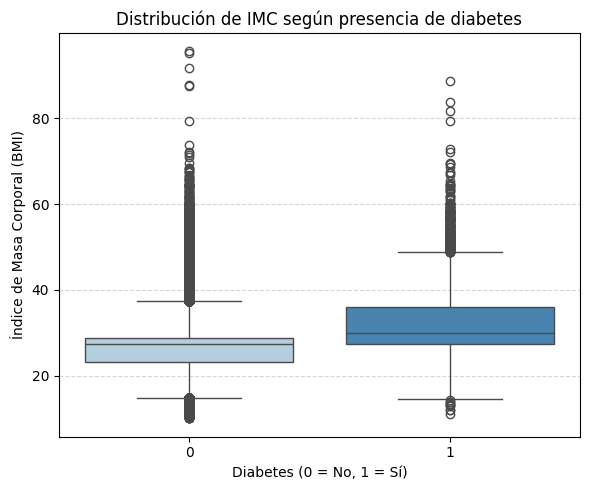

In [ ]:

# Boxplot: Distribución de BMI según si tiene o no diabetes
plt.figure(figsize=(6, 5))
sns.boxplot(x='diabetes', y='bmi', data=train_df, palette='Blues')

# Detalles del gráfico
plt.title("Distribución de IMC según presencia de diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Sí)")
plt.ylabel("Índice de Masa Corporal (BMI)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


con este grafico queremos validar si hay diferencia en el índice de masa corporal entre personas con y sin diabetes.

En este ejemplo, quienes tienen diabetes tienen ligeramente mayor BMI.

#### 2.2) DATA SET TEST

In [ ]:
# Cargar los datos de testeo
#from google.colab import files
#uploaded = files.upload()

test_df = pd.read_csv('diabetes_prediction_dataset_test.csv')

Saving diabetes_prediction_dataset_test.csv to diabetes_prediction_dataset_test.csv


Hacemos un analisis estadistico y descriptivo del set de datos de entrenamiento

In [ ]:
# Imprimir el tamaño del set de datos
print(f"El set de datos de testo tiene {test_df.shape[0]} filas y {train_df.shape[1]} columnas.")
test_df.head()

El set de datos de testo tiene 5000 filas y 10 columnas.


,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN


Analisis estadistico

In [ ]:
# Mostrar el análisis estadístico descriptivo
display(test_df.describe())

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,0.0
mean,49696.473600,40.947016,0.070600,0.038600,27.318644,5.524620,137.821000,NaN
std,28855.568156,22.537466,0.256181,0.192659,6.832943,1.078559,40.101933,NaN
min,7.000000,0.160000,0.000000,0.000000,10.620000,3.500000,80.000000,NaN
25%,24720.750000,23.000000,0.000000,0.000000,23.410000,4.800000,100.000000,NaN
50%,49522.500000,41.000000,0.000000,0.000000,27.320000,5.800000,140.000000,NaN
75%,74686.000000,59.000000,0.000000,0.000000,29.632500,6.200000,159.000000,NaN
max,99970.000000,80.000000,1.000000,1.000000,88.760000,9.000000,300.000000,NaN


Se muestra la informacion general

In [ ]:
# Mostrar información general del set de datos
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              5000 non-null   int64  
 1   gender               5000 non-null   object 
 2   age                  5000 non-null   float64
 3   hypertension         5000 non-null   int64  
 4   heart_disease        5000 non-null   int64  
 5   smoking_history      5000 non-null   object 
 6   bmi                  5000 non-null   float64
 7   HbA1c_level          5000 non-null   float64
 8   blood_glucose_level  5000 non-null   int64  
 9   diabetes             0 non-null      float64
dtypes: float64(4), int64(4), object(2)
memory usage: 390.8+ KB


##### Visualización general de la distribución de las variables numéricas.

array([[<Axes: title={'center': 'patient'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hypertension'}>],
       [<Axes: title={'center': 'heart_disease'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'HbA1c_level'}>],
       [<Axes: title={'center': 'blood_glucose_level'}>,
        <Axes: title={'center': 'diabetes'}>, <Axes: >]], dtype=object)

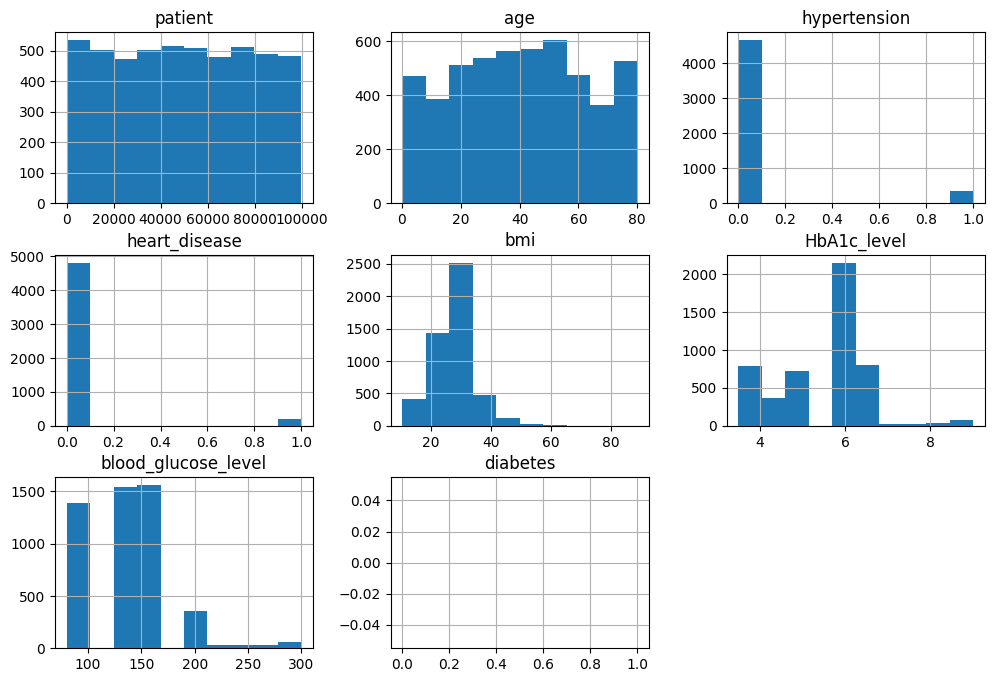

In [ ]:
test_df.hist(figsize=(12, 8))

##### Variable categorica gender

In [ ]:
# Contar los valores únicos en la columna 'gender' de todo nuestro dataset
print(test_df['gender'].value_counts())

gender
Female    2989
Male      2009
Other        2
Name: count, dtype: int64


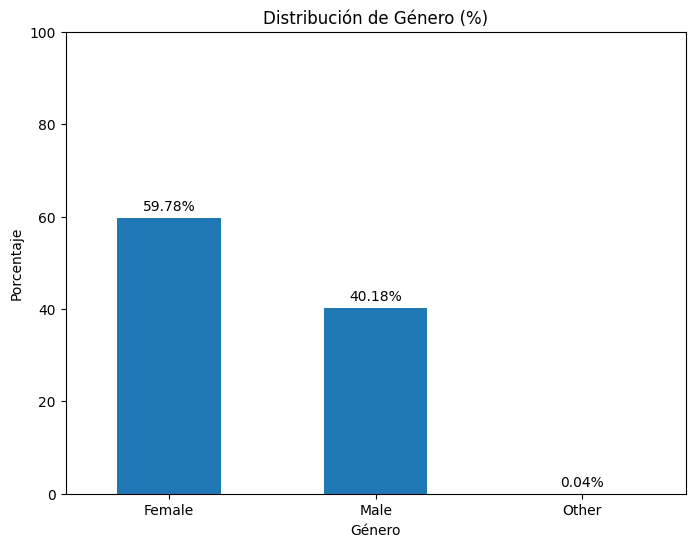

In [ ]:
# Calcular conteos y porcentajes de género
gender_counts = test_df['gender'].value_counts()
gender_percentages = gender_counts / len(test_df) * 100

plt.figure(figsize=(8, 6))
bars = gender_percentages.plot(kind='bar')
plt.title('Distribución de Género (%)')
plt.xlabel('Género')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Añadir etiquetas de porcentaje a las barras
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')

plt.show()

##### Variable age

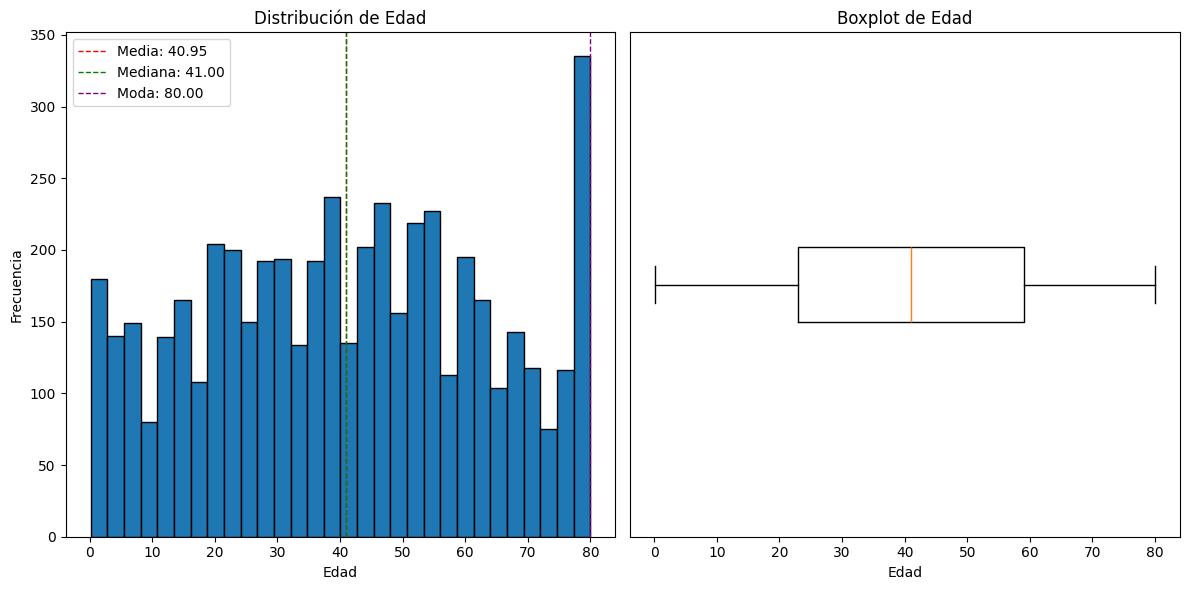

In [ ]:
plt.figure(figsize=(12, 6))

# Calcular media, mediana y moda
mean_age = test_df['age'].mean()
median_age = test_df['age'].median()
# Moda puede tener múltiples valores, tomamos el primero si existe
mode_age = test_df['age'].mode()
if not mode_age.empty:
    mode_age_val = mode_age[0]
else:
    mode_age_val = None


# Histograma de age
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.hist(test_df['age'], bins=30, edgecolor='black')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Añadir líneas para media, mediana y moda
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=1, label=f'Media: {mean_age:.2f}')
plt.axvline(median_age, color='green', linestyle='dashed', linewidth=1, label=f'Mediana: {median_age:.2f}')
if mode_age_val is not None:
    plt.axvline(mode_age_val, color='purple', linestyle='dashed', linewidth=1, label=f'Moda: {mode_age_val:.2f}')

plt.legend()

# Boxplot de age
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.boxplot(test_df['age'], vert=False)
plt.title('Boxplot de Edad')
plt.xlabel('Edad')
plt.yticks([]) # Ocultar etiquetas del eje y para el boxplot

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##### Variable hypertension   

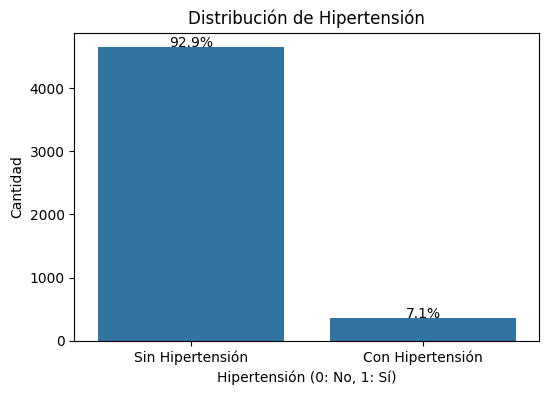

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='hypertension', data=test_df)
plt.title('Distribución de Hipertensión')
plt.xlabel('Hipertensión (0: No, 1: Sí)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Sin Hipertensión', 'Con Hipertensión'])

# Añadir porcentajes encima de las barras
total = len(test_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(100 * height/total),
            ha="center")

plt.show()

##### Variable heart_disease

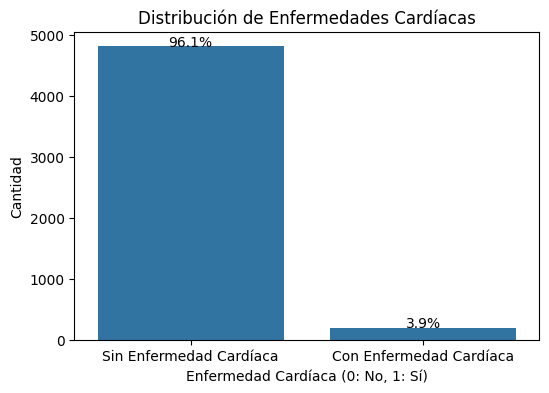

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='heart_disease', data=test_df)
plt.title('Distribución de Enfermedades Cardíacas')
plt.xlabel('Enfermedad Cardíaca (0: No, 1: Sí)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Sin Enfermedad Cardíaca', 'Con Enfermedad Cardíaca'])

# Añadir porcentajes encima de las barras
total = len(test_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(100 * height/total),
            ha="center")

plt.show()

##### Variable smoking_history

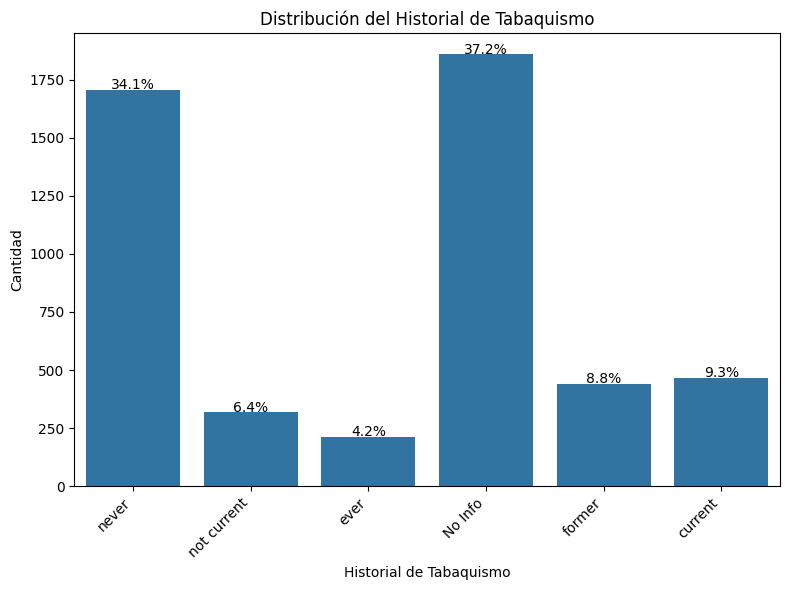

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='smoking_history', data=test_df)
plt.title('Distribución del Historial de Tabaquismo')
plt.xlabel('Historial de Tabaquismo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

# Añadir porcentajes encima de las barras
total = len(test_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(100 * height/total),
            ha="center")

plt.tight_layout()
plt.show()

##### Variable bmi   

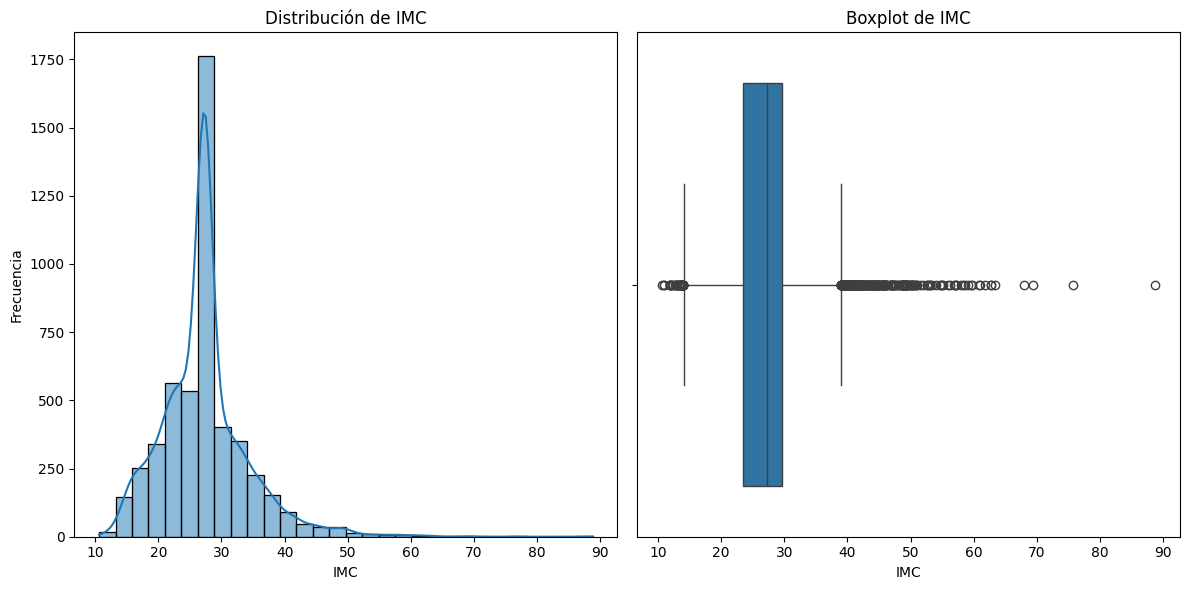

In [ ]:
plt.figure(figsize=(12, 6))

# Histograma de bmi
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(data=test_df, x='bmi', bins=30, kde=True)
plt.title('Distribución de IMC')
plt.xlabel('IMC')
plt.ylabel('Frecuencia')

# Boxplot de bmi
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(data=test_df, x='bmi')
plt.title('Boxplot de IMC')
plt.xlabel('IMC')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##### Variable HbA1c_level

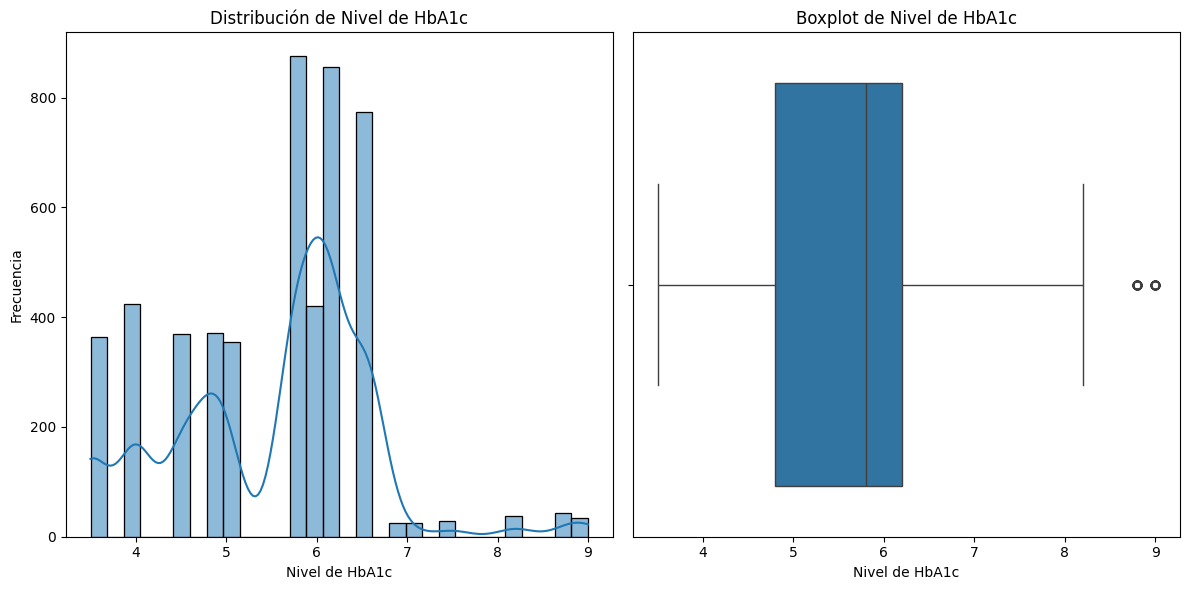

In [ ]:
plt.figure(figsize=(12, 6))

# Histograma de HbA1c_level
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(data=test_df, x='HbA1c_level', bins=30, kde=True)
plt.title('Distribución de Nivel de HbA1c')
plt.xlabel('Nivel de HbA1c')
plt.ylabel('Frecuencia')

# Boxplot de HbA1c_level
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(data=test_df, x='HbA1c_level')
plt.title('Boxplot de Nivel de HbA1c')
plt.xlabel('Nivel de HbA1c')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##### Variable blood_glucose_level

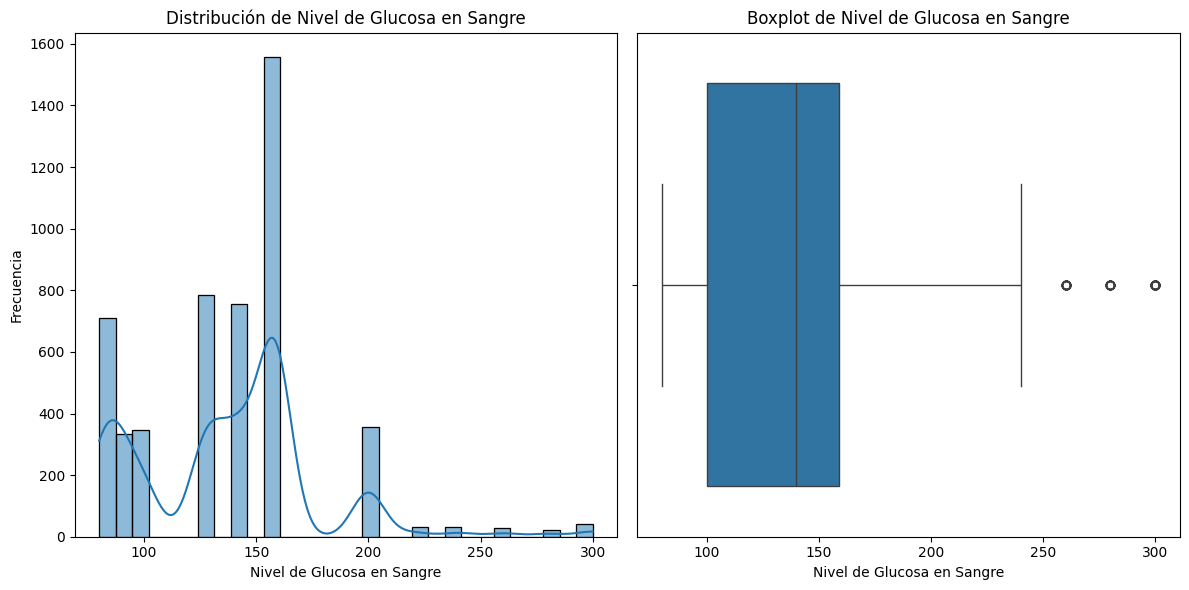

In [ ]:
plt.figure(figsize=(12, 6))

# Histograma de blood_glucose_level
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(data=test_df, x='blood_glucose_level', bins=30, kde=True)
plt.title('Distribución de Nivel de Glucosa en Sangre')
plt.xlabel('Nivel de Glucosa en Sangre')
plt.ylabel('Frecuencia')

# Boxplot de blood_glucose_level
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(data=test_df, x='blood_glucose_level')
plt.title('Boxplot de Nivel de Glucosa en Sangre')
plt.xlabel('Nivel de Glucosa en Sangre')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

### 3) SET DE ENTRENAMIENTO Y TESTEO

Se hace la division entre train y test

In [ ]:
imputer_cols = ["patient", "age", "hypertension", "heart_disease", "bmi" ,"HbA1c_level", "blood_glucose_level", "diabetes"]
imputer = SimpleImputer(strategy="median")
train_df[imputer_cols] = imputer.fit_transform(train_df[imputer_cols])
y = train_df.diabetes
X = train_df.drop('diabetes',axis=1)

Se separa la columna con los Id de los pacientes en una sola variable

In [ ]:
patientId = X.patient
X.drop('patient',axis=1,inplace=True)

Se hace el Encoding del set de entrenamiento mediante get_dummies

In [ ]:
X = pd.get_dummies(X, columns=['gender', 'smoking_history'], drop_first=True, dtype=int)

Se dividen los datos en conjuntos de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones del conjunto de entrenamiento (X_train, y_train):", X_train.shape, y_train.shape)
print("Dimensiones del conjunto de prueba (X_test, y_test):", X_test.shape, y_test.shape)

#Nos aseguramos que no quede ningun null
print(X.isnull().sum().sort_values(ascending=False).head())

Dimensiones del conjunto de entrenamiento (X_train, y_train): (76000, 13) (76000,)
Dimensiones del conjunto de prueba (X_test, y_test): (19000, 13) (19000,)
age              0
hypertension     0
heart_disease    0
bmi              0
HbA1c_level      0
dtype: int64


In [ ]:
X

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,4.0,0.0,0.0,19.28,3.5,155.0,1,0,0,0,0,1,0
1,50.0,0.0,0.0,27.32,5.7,159.0,0,0,0,0,1,0,0
2,43.0,0.0,0.0,21.54,4.5,145.0,0,0,0,0,0,1,0
3,64.0,0.0,0.0,28.22,6.0,130.0,1,0,1,0,0,0,0
4,10.0,0.0,0.0,15.46,6.1,140.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,56.0,0.0,0.0,22.30,6.2,158.0,0,0,0,0,0,1,0
94996,24.0,0.0,0.0,22.50,6.1,126.0,0,0,0,0,0,1,0
94997,32.0,0.0,0.0,24.92,6.6,145.0,0,0,0,0,0,1,0
94998,21.0,0.0,0.0,20.59,4.5,155.0,0,0,1,0,0,0,0


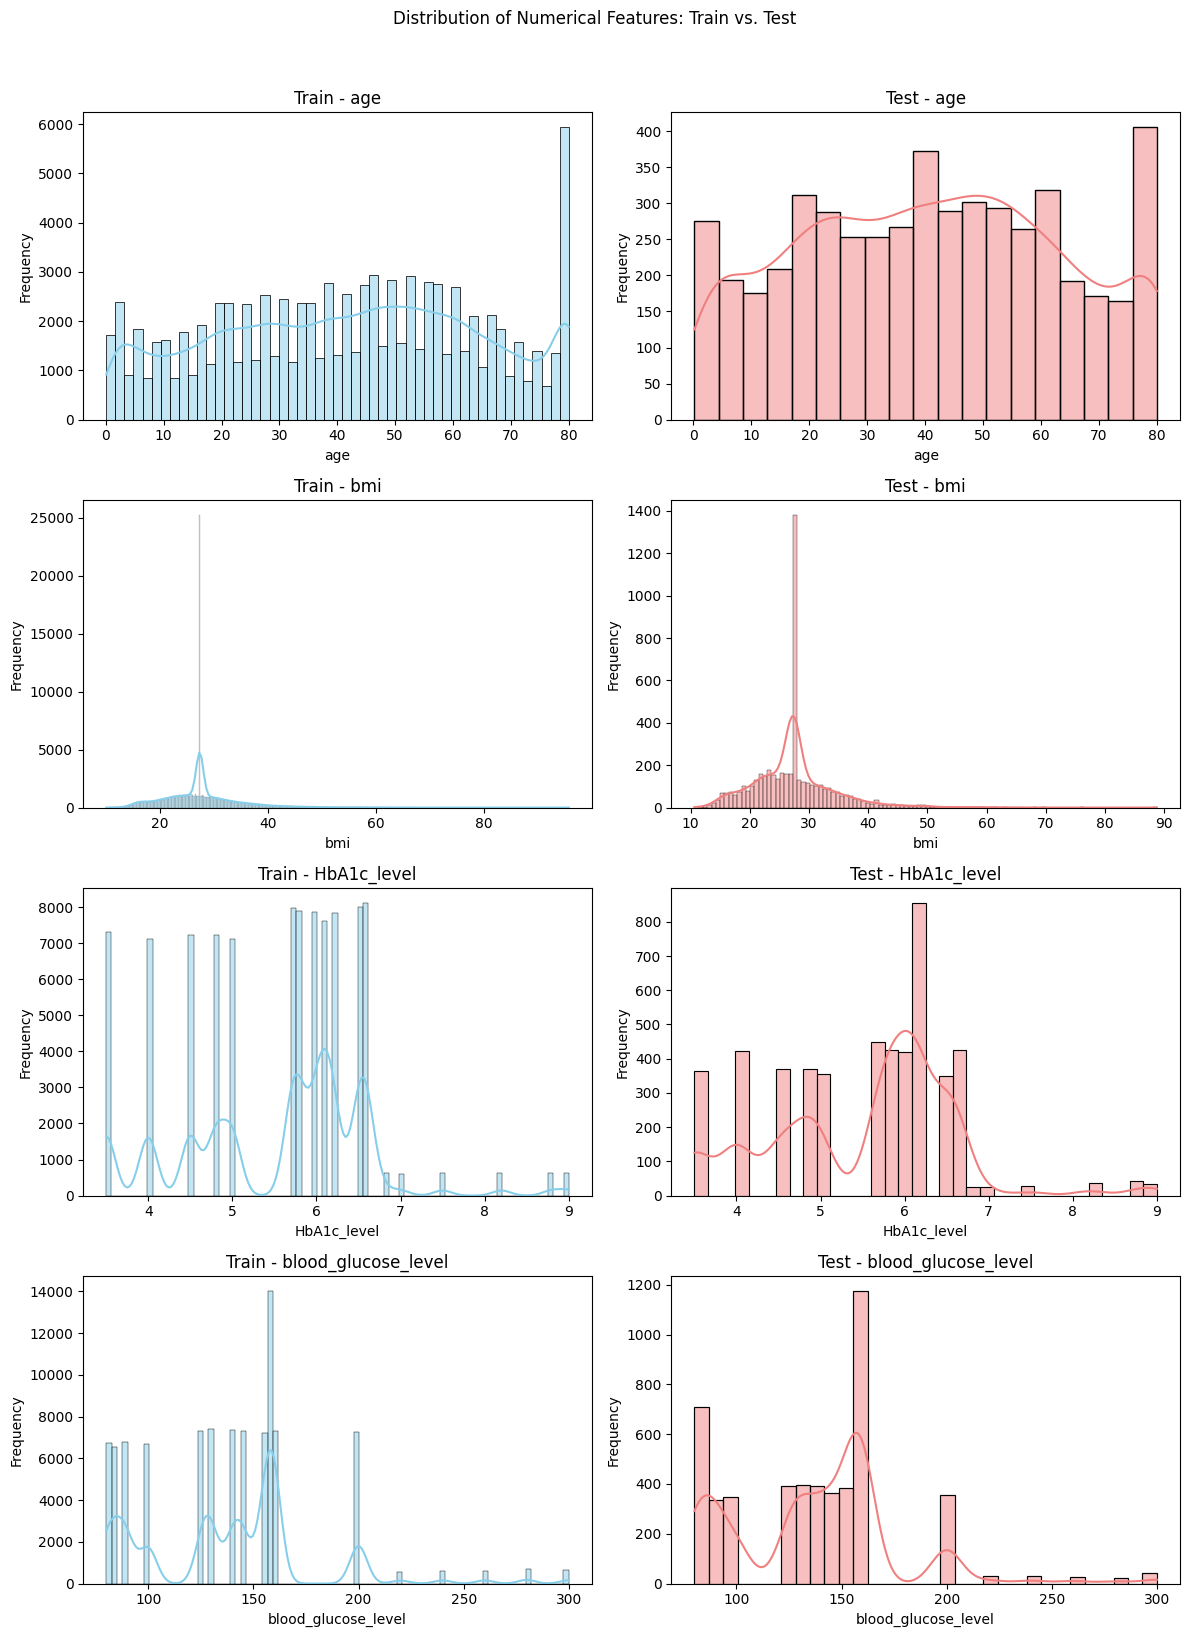

In [ ]:
# Select numerical columns for plotting (excluding 'patient' and 'diabetes')
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Create subplots for each numerical column
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, 4 * len(numerical_cols)))

fig.suptitle('Distribution of Numerical Features: Train vs. Test', y=1.02)

for i, col in enumerate(numerical_cols):
    # Histogram for training data
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Train - {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Histogram for test data
    sns.histplot(data=test_df, x=col, kde=True, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Test - {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 4) MODELOS

#### 4.1) REDES NEURONALES

Hacemos una normalizacion y escalado

Dimensiones del conjunto de entrenamiento escalado: (76000, 13)
Dimensiones del conjunto de prueba escalado: (19000, 13)


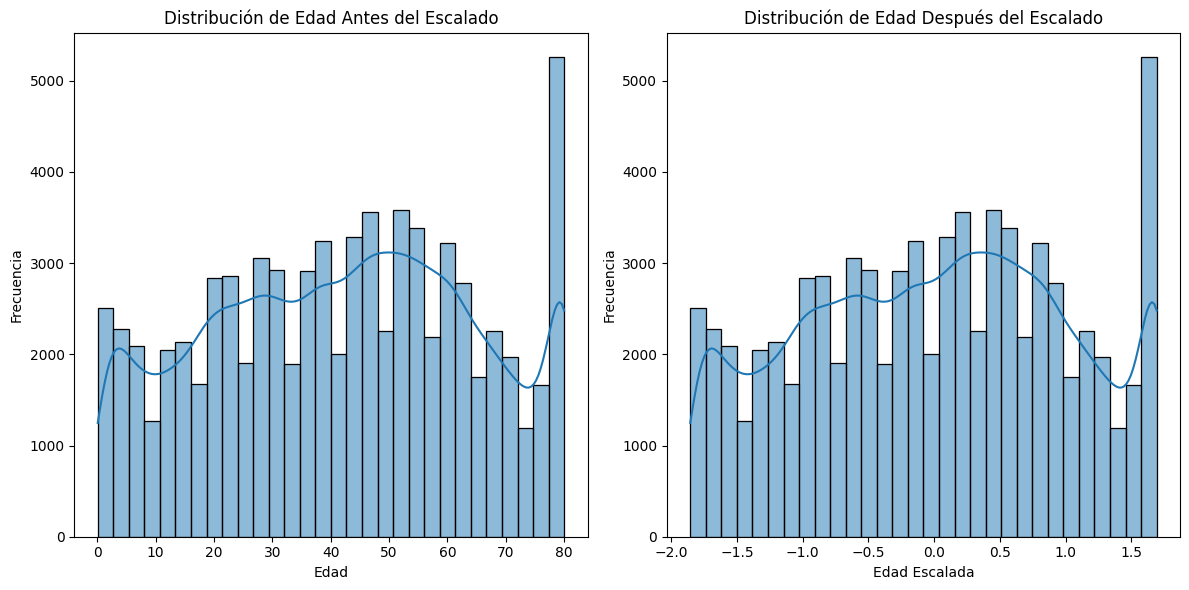

In [ ]:
# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el escalador a los datos de entrenamiento y transformarlos
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando el mismo escalador
X_test_scaled = scaler.transform(X_test)

print("Dimensiones del conjunto de entrenamiento escalado:", X_train_scaled.shape)
print("Dimensiones del conjunto de prueba escalado:", X_test_scaled.shape)


# Encontrar el índice de la columna 'age' en el DataFrame original X_train
age_col_index = X_train.columns.get_loc('age')

# Extraer la columna 'age' antes del escalado
age_before_scaling = X_train['age']

# Extraer la columna 'age' escalada usando el índice de los datos escalados
age_after_scaling = X_train_scaled[:, age_col_index]

# Trazar los histogramas
plt.figure(figsize=(12, 6))

# Histograma antes del escalado
plt.subplot(1, 2, 1)
sns.histplot(age_before_scaling, bins=30, kde=True)
plt.title('Distribución de Edad Antes del Escalado')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Histograma después del escalado
plt.subplot(1, 2, 2)
sns.histplot(age_after_scaling, bins=30, kde=True)
plt.title('Distribución de Edad Después del Escalado')
plt.xlabel('Edad Escalada')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Ademas como las clases de personas con y sin diabetes estan desbalanceadas, balancearemos el set con SMOTE

In [ ]:
# Aplicar SMOTE para balancear las clases
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Distribución original:", np.bincount(y_train))
print("Distribución tras SMOTE:", np.bincount(y_resampled))


Distribución original: [69534  6466]
Distribución tras SMOTE: [69534 69534]


##### 4.1.1) MLPClassifier con parametros

Definimos el modelo de prediccion con los siguientes parametros

In [ ]:
# Modelo
redNeuronal = neural_network.MLPClassifier(
    solver='sgd',
    alpha=1e-4,
    hidden_layer_sizes=(64, 32, 16), #definimos multiples capas con multiples neuronas para complejizar el modelo
    learning_rate='constant',
    learning_rate_init=0.001,
    batch_size=20,
    random_state=1,
    max_iter=200,
    verbose=True)

# Entrenar el modelo
redNeuronal.fit(X_resampled, y_resampled)


Iteration 1, loss = 0.25736516
Iteration 2, loss = 0.22983892
Iteration 3, loss = 0.21793806
Iteration 4, loss = 0.21024192
Iteration 5, loss = 0.20506681
Iteration 6, loss = 0.20058618
Iteration 7, loss = 0.19662097
Iteration 8, loss = 0.19271663
Iteration 9, loss = 0.18944023
Iteration 10, loss = 0.18679919
Iteration 11, loss = 0.18426339
Iteration 12, loss = 0.18173665
Iteration 13, loss = 0.17988858
Iteration 14, loss = 0.17818352
Iteration 15, loss = 0.17661792
Iteration 16, loss = 0.17522967
Iteration 17, loss = 0.17358766
Iteration 18, loss = 0.17229551
Iteration 19, loss = 0.17119505
Iteration 20, loss = 0.16992505
Iteration 21, loss = 0.16916145
Iteration 22, loss = 0.16823723
Iteration 23, loss = 0.16748551
Iteration 24, loss = 0.16667300
Iteration 25, loss = 0.16573071
Iteration 26, loss = 0.16510200
Iteration 27, loss = 0.16421850
Iteration 28, loss = 0.16415211
Iteration 29, loss = 0.16325945
Iteration 30, loss = 0.16259975
Iteration 31, loss = 0.16211633
Iteration 32, los

MLPClassifier(batch_size=20, hidden_layer_sizes=(64, 32, 16), random_state=1,
              solver='sgd', verbose=True)

--- Métricas para el Conjunto de Prueba ---
Precisión: 0.912

Informe de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      0.92      0.95     17384
         1.0       0.49      0.84      0.62      1616

    accuracy                           0.91     19000
   macro avg       0.74      0.88      0.79     19000
weighted avg       0.94      0.91      0.92     19000



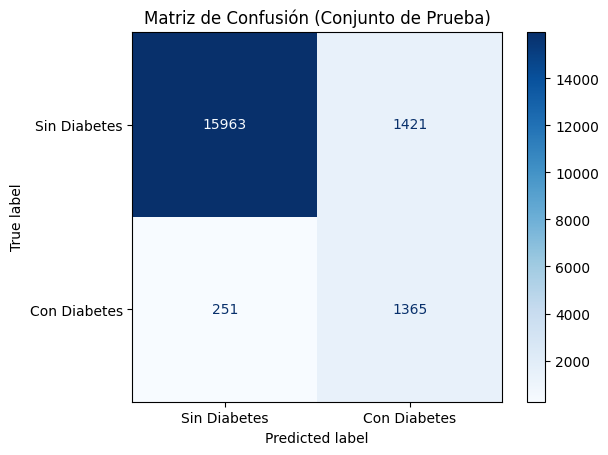


--- Métricas para el Conjunto de Entrenamiento ---
Precisión: 0.9318421052631579

Informe de Clasificación:
               precision    recall  f1-score   support

         0.0       0.99      0.93      0.96     69534
         1.0       0.56      0.94      0.70      6466

    accuracy                           0.93     76000
   macro avg       0.78      0.93      0.83     76000
weighted avg       0.96      0.93      0.94     76000



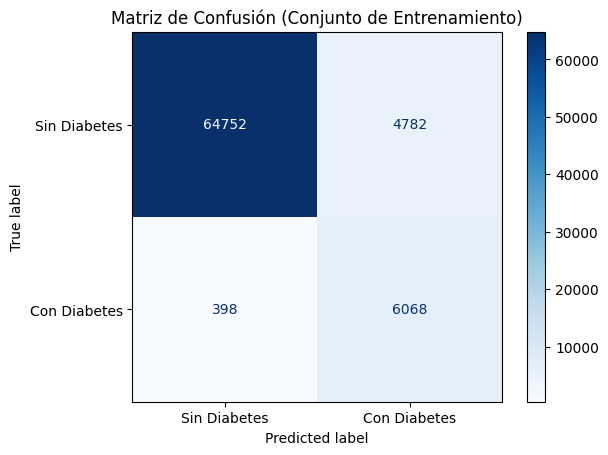

In [ ]:
# Realizar predicciones en los datos de prueba escalados
y_pred_test = redNeuronal.predict(X_test_scaled)

# Calcular e imprimir métricas para el conjunto de prueba
print("--- Métricas para el Conjunto de Prueba ---")
print("Precisión:", accuracy_score(y_test, y_pred_test))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_test))

# Mostrar Matriz de Confusión para el conjunto de prueba
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Prueba)')
plt.show()

# Realizar predicciones en los datos de entrenamiento escalados
y_pred_train = redNeuronal.predict(X_train_scaled)

# Calcular e imprimir métricas para el conjunto de entrenamiento
print("\n--- Métricas para el Conjunto de Entrenamiento ---")
print("Precisión:", accuracy_score(y_train, y_pred_train))
print("\nInforme de Clasificación:\n", classification_report(y_train, y_pred_train))

# Mostrar Matriz de Confusión para el conjunto de entrenamiento
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Entrenamiento)')
plt.show()

##### 4.1.2) MLPClassifier (mejor modelo)

In [ ]:
# Esta comentada ya que demora mucho tiempo para la ejecucion

"""# Definir la grilla de parámetros para buscar
param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,),(10, 5), (20, 10),(20, 10, 5), (30, 20, 10)], # Ejemplo de tamaños de capa
    'activation': ['relu', 'tanh', 'logistic'], # Funciones de activación
    'solver': ['sgd', 'adam'], # Tipos de solucionadores
    'alpha': [0.0001, 0.001, 0.01], # Parámetro de penalización L2 (regularización)
    'learning_rate_init': [0.001, 0.01, 0.1], # Tasa de aprendizaje inicial
    'max_iter': [10] # Número de iteraciones (reducido para ejemplo rápido)
}

# Inicializar el MLPClassifier con otros parámetros
# Usar los mismos parámetros que tu modelo redNeuronal como base (excluyendo class_weight)
mlp = MLPClassifier(random_state=1, batch_size=20, learning_rate='constant')

# Inicializar GridSearchCV
# Usar el evaluador recall para maximizarlo
# n_jobs=-1 usa todos los procesadores disponibles
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=3, scoring='recall', verbose=2, n_jobs=-1)

# Realizar la búsqueda en grilla
grid_search.fit(X_train_scaled, y_train.to_numpy())

# Imprimir los mejores parámetros y la mejor puntuación
print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor recall (minimizado):", grid_search.best_score_)

# Obtener el mejor modelo
best_model = grid_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_best = best_model.predict(X_test_scaled)

# Calcular e imprimir métricas para el mejor modelo
print("\n--- Métricas para el Mejor Modelo (Conjunto de Prueba) ---")
print("Precisión:", accuracy_score(y_test, y_pred_best))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_best))

# Mostrar Matriz de Confusión para el mejor modelo
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_best.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Mejor Modelo - Conjunto de Prueba)')
plt.show()"""

In [ ]:
# Definir el modelo MLPClassifier con los parámetros elegidos
redNeuronal_mejorModelo = MLPClassifier(
    activation= 'tanh',
    alpha= 0.0001,
    hidden_layer_sizes= (20,),
    learning_rate_init= 0.1,
    max_iter= 200,
    solver= 'sgd',
    learning_rate='constant',
    batch_size='auto',
    random_state=1,
   )


# Definir las métricas de evaluación para la validación cruzada
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Realizar validación cruzada (ejemplo con accuracy)
# Usando los datos de entrenamiento escalados (X_train_scaled, y_train)
cv_results = cross_val_score(
    redNeuronal_mejorModelo,
    X_train_scaled,
    y_train.to_numpy(),
    cv=5, # Usando validación cruzada de 5 folds
    scoring=make_scorer(accuracy_score) # Calcular accuracy por defecto
)

# Imprimir resultados de validación cruzada (media y desviación estándar)
print("Precisión de Validación Cruzada: %0.2f (+/- %0.2f)" % (cv_results.mean(), cv_results.std() * 2))


# Para obtener todas las métricas, usar cross_validate
cv_results_multi = cross_validate(
    redNeuronal_mejorModelo,
    X_train_scaled,
    y_train.to_numpy(),
    cv=5, # Usando validación cruzada de 5 folds
    scoring=scoring
)

print("\nResultados de Validación Cruzada (Media +/- 2*Desviación Estándar):")
for metric_name, metric_values in cv_results_multi.items():
    if metric_name.startswith('test_'):
        mean_score = metric_values.mean()
        std_score = metric_values.std() * 2
        # Traducir nombres de métricas si es necesario
        translated_metric_name = metric_name[5:].replace('accuracy', 'Precisión').replace('precision', 'Precisión (Clase Positiva)').replace('recall', 'Recall (Sensibilidad)').replace('f1', 'F1-Score')
        print(f"{translated_metric_name.capitalize()}: %0.2f (+/- %0.2f)" % (mean_score, std_score))

Precisión de Validación Cruzada: 0.97 (+/- 0.00)

Resultados de Validación Cruzada (Media +/- 2*Desviación Estándar):
Precisión: 0.97 (+/- 0.00)
Precisión (clase positiva): 0.98 (+/- 0.01)
Recall (sensibilidad): 0.68 (+/- 0.02)
F1-score: 0.80 (+/- 0.01)


In [ ]:
# Entrenar el modelo en todo el conjunto de entrenamiento
redNeuronal_mejorModelo.fit(X_train_scaled, y_train.to_numpy())

print("Modelo entrenado correctamente en el conjunto de entrenamiento.")

Modelo entrenado correctamente en el conjunto de entrenamiento.


##### 4.1.3) XGBOOST (BALANCEADO)


 XGBoost (Balanced) - Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0      0.988     0.923     0.954     17384
         1.0      0.514     0.877     0.648      1616

    accuracy                          0.919     19000
   macro avg      0.751     0.900     0.801     19000
weighted avg      0.947     0.919     0.928     19000

Recall: 0.877 | AUC: 0.975


##### 4.1.4) DATOS DE SALIDA

In [ ]:
test_df = pd.read_csv('diabetes_prediction_dataset_test.csv')

Para poder evaluar nuestra predicción los datos de prueba deben tener exactamente el mismo tratamiento que los datos de entrenamiento

In [ ]:
Y_test_salida = test_df.diabetes
PatientId_test = test_df['patient']
X_test_salida = test_df.drop(['patient','diabetes'],axis=1)

In [ ]:
imputer_cols = ["age", "hypertension", "heart_disease", "bmi" ,"HbA1c_level", "blood_glucose_level"]
imputer = SimpleImputer(strategy="median")
X_test_salida[imputer_cols] = imputer.fit_transform(X_test_salida[imputer_cols])

In [ ]:
X_test_salida = pd.get_dummies(X_test_salida, columns=['gender', 'smoking_history'], drop_first=True, dtype=int)

Generamos la salida

In [ ]:
# MODIFICAR PARA SELECCIONAR EL MODELO A UTILIZAR
test_id = PatientId_test
test_pred = np.int64(redNeuronal.predict(X_test_salida))

Con el resultado predicho tenemos que generar el archivo .csv para subir a la competencia de kaggle:

In [ ]:
submission = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
submission.to_csv("sample_submissionRedNeuronal.csv", header=True, index=False)

In [ ]:
submission

#### 4.2) SUPPORT VECTOR MACHINES

In [ ]:
# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el escalador a los datos de entrenamiento y transformarlos
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando el mismo escalador
X_test_scaled = scaler.transform(X_test)

print("Dimensiones del conjunto de entrenamiento escalado:", X_train_scaled.shape)
print("Dimensiones del conjunto de prueba escalado:", X_test_scaled.shape)

##### 4.2.1) SVM con parametros por defectos

In [ ]:
from sklearn.svm import SVC

# Definir un modelo SVM con parámetros por defecto
svm = SVC()

# Entrenar el modelo SVM con los datos escalados
svm.fit(X_train_scaled, y_train)


In [ ]:
# Realizar predicciones en los datos de prueba escalados

y_pred_test = svm.predict(X_test_scaled)

# Calcular e imprimir métricas para el conjunto de prueba
print("--- Métricas para el Conjunto de Prueba ---")
print("Precisión:", accuracy_score(y_test, y_pred_test))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_test))

# Mostrar Matriz de Confusión para el conjunto de prueba
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Prueba)')
plt.show()

# Realizar predicciones en los datos de entrenamiento escalados
y_pred_train = svm.predict(X_train_scaled)

# Calcular e imprimir métricas para el conjunto de entrenamiento
print("\n--- Métricas para el Conjunto de Entrenamiento ---")
print("Precisión:", accuracy_score(y_train, y_pred_train))
print("\nInforme de Clasificación:\n", classification_report(y_train, y_pred_train))

# Mostrar Matriz de Confusión para el conjunto de entrenamiento
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Entrenamiento)')
plt.show()

##### 4.2.2) SVM (class_weight='balanced')  

In [ ]:
# Definir un modelo SVM
wsvm = SVC(class_weight='balanced')

# Entrenar el modelo SVM con los datos escalados
wsvm.fit(X_train_scaled, y_train)

# Realizar predicciones en los datos de prueba escalados
# Use the scaled X_test from the original train-test split for prediction
y_pred_test = wsvm.predict(X_test_scaled)

# Calcular e imprimir métricas para el conjunto de prueba
print("--- Métricas para el Conjunto de Prueba ---")
print("Precisión:", accuracy_score(y_test, y_pred_test))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_test))

# Mostrar Matriz de Confusión para el conjunto de prueba
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Prueba)')
plt.show()

# Realizar predicciones en los datos de entrenamiento escalados
y_pred_train = wsvm.predict(X_train_scaled)

# Calcular e imprimir métricas para el conjunto de entrenamiento
print("\n--- Métricas para el Conjunto de Entrenamiento ---")
print("Precisión:", accuracy_score(y_train, y_pred_train))
print("\nInforme de Clasificación:\n", classification_report(y_train, y_pred_train))

# Mostrar Matriz de Confusión para el conjunto de entrenamiento
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Entrenamiento)')
plt.show()

##### 4.2.3) SVM (mejor modelo)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer
from sklearn.model_selection import train_test_split

# Crear un subconjunto del 10% de los datos de entrenamiento para GridSearchCV
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train_scaled, y_train, test_size=0.9, random_state=42, stratify=y_train
)

print(f"Tamaño del subconjunto de entrenamiento para GridSearchCV: {X_train_subset.shape[0]} filas")

# Definir la grilla de parámetros para buscar
param_grid = {
    'C': [0.1, 1, 10],  # Parámetro de regularización
    'gamma': ['scale', 'auto'], # Coeficiente del kernel
    'kernel': ['rbf', 'linear','sigmoid','poly'], # Tipo de kernel
    'degree':[1,2,3,4,5]
}

# Inicializar el SVM
svm = SVC(random_state=42)

# Definir el scorer para maximizar recall
recall_scorer = make_scorer(recall_score)

# Inicializar GridSearchCV
# cv=3 para validación cruzada de 3 folds
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=3, scoring=recall_scorer, verbose=2, n_jobs=-1)

# Realizar la búsqueda en grilla en el subconjunto de datos
grid_search.fit(X_train_subset, y_train_subset)

# Imprimir los mejores parámetros y la mejor puntuación
print("\nMejores parámetros encontrados:", grid_search.best_params_)
print("Mejor recall encontrado:", grid_search.best_score_)

# Obtener el mejor modelo
best_svm_model = grid_search.best_estimator_

print("\nMejor modelo SVM encontrado:")
print(best_svm_model)

In [ ]:
# Definir un modelo SVM
svmMejorModelo = SVC(C=10,degree=3, gamma='scale',kernel='poly')

# Entrenar el modelo SVM con los datos escalados
svmMejorModelo.fit(X_train_scaled, y_train)

# Realizar predicciones en los datos de prueba escalados
y_pred_test = svmMejorModelo.predict(X_test_scaled)

# Calcular e imprimir métricas para el conjunto de prueba
print("--- Métricas para el Conjunto de Prueba ---")
print("Precisión:", accuracy_score(y_test, y_pred_test))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_test))

# Mostrar Matriz de Confusión para el conjunto de prueba
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Prueba)')
plt.show()

# Realizar predicciones en los datos de entrenamiento escalados
y_pred_train = svmMejorModelo.predict(X_train_scaled)

# Calcular e imprimir métricas para el conjunto de entrenamiento
print("\n--- Métricas para el Conjunto de Entrenamiento ---")
print("Precisión:", accuracy_score(y_train, y_pred_train))
print("\nInforme de Clasificación:\n", classification_report(y_train, y_pred_train))

# Mostrar Matriz de Confusión para el conjunto de entrenamiento
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Sin Diabetes', 'Con Diabetes'])
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Conjunto de Entrenamiento)')
plt.show()

Analizando los **Falsos positivos** contra los **Verdaderos positivos**

In [ ]:
# Identify false negatives: actual diabetes (y_test == 1) but predicted no diabetes (y_pred_test == 0)
false_negatives_indices = (y_test == 1) & (y_pred_test == 0)

# Identify true positives: actual diabetes (y_test == 1) and predicted diabetes (y_pred_test == 1)
true_positives_indices = (y_test == 1) & (y_pred_test == 1)

# Filter the original test DataFrame to get the false negative and true positive records
# Need to reset index of y_test and y_pred_test to align with X_test
y_test_reset = y_test.reset_index(drop=True)
y_pred_test_series = pd.Series(y_pred_test, index=X_test.index)

false_negatives_indices_aligned = (y_test_reset == 1) & (y_pred_test_series == 0)
true_positives_indices_aligned = (y_test_reset == 1) & (y_pred_test_series == 1)


false_negatives_df = X_test.loc[false_negatives_indices_aligned]
true_positives_df = X_test.loc[true_positives_indices_aligned]

print(f"Number of False Negatives in the test set: {false_negatives_df.shape[0]}")
print(f"Number of True Positives in the test set: {true_positives_df.shape[0]}")

# Visualize the distribution of all variables for false negatives and true positives
for col in X_test.columns: # Iterate through columns of the original X_test for consistency
    plt.figure(figsize=(8, 6))
    if X_test[col].dtype in ['int64', 'float64']:
        sns.histplot(data=false_negatives_df, x=col, bins=20, kde=True, color='salmon', label='False Negatives', stat='density', common_norm=False)
        sns.histplot(data=true_positives_df, x=col, bins=20, kde=True, color='skyblue', label='True Positives', stat='density', common_norm=False)
        plt.title(f'Distribution of {col}: False Negatives vs. True Positives')
        plt.xlabel(col)
        plt.ylabel('Density')
    else:
        # For categorical variables, use countplot
        sns.countplot(data=false_negatives_df, x=col, color='salmon', label='False Negatives')
        sns.countplot(data=true_positives_df, x=col, color='skyblue', label='True Positives')
        plt.title(f'Distribution of {col}: False Negatives vs. True Positives')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')

    plt.legend()
    plt.tight_layout()
    plt.show()

* Age: Se observan que los True Positive se concentran en las edades mas altas, mientras que los False Positive, esta presentes en todo el rango de edades.
* HbA1c_level y blood_glucose_level: Se observa que para valores elevados esta la mayor concentracion de True Positives mientras que para niveles bajos se encuentran muchos False Positives.

##### 4.2.4) DATOS DE SALIDA

In [ ]:
test_df = pd.read_csv('diabetes_prediction_dataset_test.csv')

Para poder evaluar nuestra predicción los datos de prueba deben tener exactamente el mismo tratamiento que los datos de entrenamiento

In [ ]:
Y_test_salida = test_df.diabetes
PatientId_test = test_df['patient']
X_test_salida = test_df.drop(['patient','diabetes'],axis=1)

In [ ]:
imputer_cols = ["age", "hypertension", "heart_disease", "bmi" ,"HbA1c_level", "blood_glucose_level"]
imputer = SimpleImputer(strategy="median")
X_test_salida[imputer_cols] = imputer.fit_transform(X_test_salida[imputer_cols])

In [ ]:
X_test_salida = pd.get_dummies(X_test_salida, columns=['gender', 'smoking_history'], drop_first=True, dtype=int)

Generamos la salida

In [ ]:
# MODIFICAR PARA SELECCIONAR EL MODELO A UTILIZAR
test_id = PatientId_test
test_pred = np.int64(svmMejorModelo.predict(X_test_salida))

Con el resultado predicho tenemos que generar el archivo .csv para subir a la competencia de kaggle:

In [ ]:
submission2 = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
submission2.to_csv("sample_submissionSVM.csv", header=True, index=False)

In [ ]:
submission2

#### 4.3) MODELO XGBOOST

##### 4.3.1) XGBoost



Accuracy: 0.9706842105263158

Matriz de Confusión:
[[17328    56]
 [  501  1115]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     17384
         1.0       0.95      0.69      0.80      1616

    accuracy                           0.97     19000
   macro avg       0.96      0.84      0.89     19000
weighted avg       0.97      0.97      0.97     19000

AUC Score: 0.977


<Figure size 800x600 with 0 Axes>

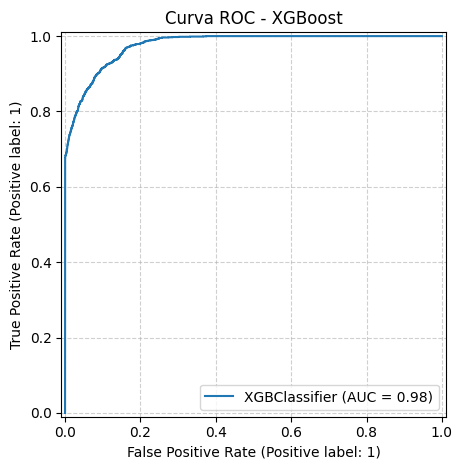

In [ ]:
##xgboost

## from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

# Crear y entrenar el modelo
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

## evaluo rendimiento
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Matriz de confusión
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

# Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb))

# AUC Score
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"AUC Score: {auc_xgb:.3f}")

### visualizo

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("Curva ROC - XGBoost")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##### 4.3.1) XGBoost (scale_pos_weight=scale_weight)

In [ ]:


# Calcular el peso de clase para el modelo
pos = y_train.sum()  # Número de positivos en el conjunto de entrenamiento
neg = len(y_train) - pos  # Número de negativos
scale_weight = neg / pos  # Calcular el peso para el balanceo de clases

xgb_balanced = XGBClassifier(
    use_label_encoder=False,  # Desactivar el uso de label encoder (obsoleto)
    eval_metric='logloss',    # Métrica para evaluar el modelo
    random_state=42,          # Establecer semilla para reproducibilidad
    scale_pos_weight=scale_weight  # Aplicar el peso de clase
)

# Entrenar
xgb_balanced.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_balanced.predict(X_test)  # Predicciones de clase
y_proba_xgb = xgb_balanced.predict_proba(X_test)[:, 1]  # Probabilidades para AUC





 XGBoost (Balanced) - Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0      0.988     0.923     0.954     17384
         1.0      0.514     0.877     0.648      1616

    accuracy                          0.919     19000
   macro avg      0.751     0.900     0.801     19000
weighted avg      0.947     0.919     0.928     19000



##### 4.3.1) DATOS DE SALIDA



 XGBoost (Balanced) - Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0      0.988     0.923     0.954     17384
         1.0      0.514     0.877     0.648      1616

    accuracy                          0.919     19000
   macro avg      0.751     0.900     0.801     19000
weighted avg      0.947     0.919     0.928     19000

Recall: 0.877 | AUC: 0.975


<Figure size 800x600 with 0 Axes>

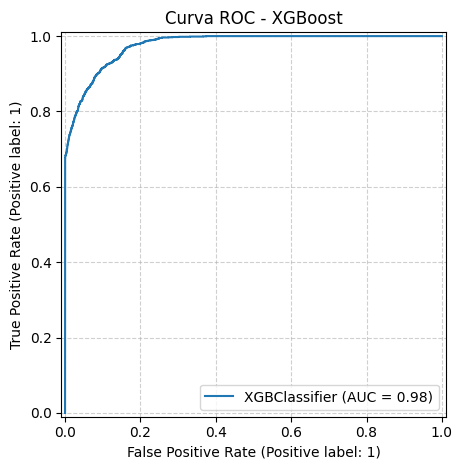

In [ ]:
# Reporte
print("\n XGBoost (Balanced) - Reporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb, digits=3))

# Calcular
xgb_recall = recall_score(y_test, y_pred_xgb)  # Recall
xgb_auc = roc_auc_score(y_test, y_proba_xgb)  # AUC


# Reporte
print(f"Recall: {xgb_recall:.3f} | AUC: {xgb_auc:.3f}")

#Visualizo
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("Curva ROC - XGBoost")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 5) COMPARACION